#### Model Performance Metrics

Creates table of model performance metrics use for each watershed and water use type (e.g. public supply, irrigation) for the calibration run. NB: these metrics for US side of watershed only as validation data only covers US side. 
\
\
Currently missing modeled thermoelectric data.

NB: metric of mean estimate (across all runs in emsemble)

In [32]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures")
out_dir.mkdir(parents=True, exist_ok=True)

In [33]:
##### ---------- MANUAL SET UP ----------

# for each calibration scenario you want included in the figure, set scenario name, run date

scenarios = [
    {
        'scenario': 'calibration',
        'run_dates': {
            'GBSJ': '2026-07-16',
            'LCRR': '2026-07-16',
            'MILK': '2026-07-16',
        }
    }
]

In [34]:
##### ---------- PREP DATA ----------

def prep_data(watershed, scenarios):

    ### ----- PREP USGS VALIDATION DATA -----
    USGS_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/USGS_validation.csv")
    USGS_data.loc[USGS_data["Watershed"] == "GBSJ", "in_us"] = 1
    USGS_data = USGS_data[USGS_data["in_us"] != 0]

    data_for_fig = USGS_data

    ### ----- LOOP OVER SCENARIOS, MERGE EACH ONE IN -----
    all_regions = pd.read_csv('/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/US_region_list.csv')
    all_regions = all_regions.rename(columns={'huc12': 'HUC12'})

    for s in scenarios:
        scenario = s['scenario']
        run_date = s['run_dates'][watershed]

        # load data
        model_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/{scenario}-{run_date}.csv")

        # filter out non-US HUCs
        model_data = model_data.merge(all_regions, on='HUC12', how='left')
        model_data.loc[model_data["Watershed"] == "GBSJ", "in_us"] = 1
        model_data = model_data[model_data["in_us"] != 0]

        # merge this scenario's columns into the growing data_for_fig
        data_for_fig = data_for_fig.merge(model_data, on=['Year', 'Watershed', 'HUC12', 'in_us'], how='outer')

    return data_for_fig

### ----- RUN FOR EACH WATERSHED -----

watersheds = ['GBSJ', 'LCRR', 'MILK']
data_for_fig = {w: prep_data(w, scenarios) for w in watersheds}

In [35]:
##### ---------- DEFINE METRIC FUNCTIONS ----------

def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    denom = np.sum((obs - obs.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((obs - sim) ** 2) / denom

def nse_components(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    if obs.std() == 0:
        return np.nan, np.nan, np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = sim.std() / obs.std()
    beta = (sim.mean() - obs.mean()) / obs.std()
    return r, alpha, beta

def kge(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    if obs.std() == 0 or obs.mean() == 0:
        return np.nan, np.nan, np.nan, np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = sim.std() / obs.std()
    beta = sim.mean() / obs.mean()
    kge_val = 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    return kge_val, r, alpha, beta


def pbias(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    if np.sum(obs) == 0:
        return np.nan
    return 100 * np.sum(sim - obs) / np.sum(obs)


def compute_all_metrics(obs, sim):
    nse_val = nse(obs, sim)
    nse_r, nse_alpha, nse_beta = nse_components(obs, sim)
    kge_val, kge_r, kge_alpha, kge_beta = kge(obs, sim)
    pbias_val = pbias(obs, sim)
    return {
        "NSE": nse_val,
        "NSE_r": nse_r,
        "NSE_alpha": nse_alpha,
        "NSE_beta": nse_beta,
        "KGE": kge_val,
        "KGE_r": kge_r,
        "KGE_alpha": kge_alpha,
        "KGE_beta": kge_beta,
        "PBIAS_%": pbias_val,
    }

In [36]:
##### ---------- COMPUTE METRICS ----------

def compute_ensemble_metrics(df, watershed):

    variables = {
        "public_supply": ("public_supply_mil_gal_validation", "public_supply_mil_gal_calibration"),
        "irrigation": ("irrigation_mil_gal_validation", "irrigation_mil_gal_calibration"),
    }

    periods = {
        "calibration_period": (2000, 2015),
        "validation_period": (2016, 2020),
    }

    metric_cols = ["NSE", "NSE_r", "NSE_alpha", "NSE_beta", "KGE", "KGE_r", "KGE_alpha", "KGE_beta", "PBIAS_%"]

    # ---- Collapse 50-member ensemble to ensemble-mean per HUC12-year,
    # THEN compute one set of metrics on that collapsed series
    # (mirrors the sampling-uncertainty script's ens_mean step) ----
    results = []

    for period_name, (y_start, y_end) in periods.items():
        period_df = df[(df["Year"] >= y_start) & (df["Year"] <= y_end)]

        for var_name, (obs_col, sim_col) in variables.items():
            ens_mean = (
                period_df.groupby(["Year", "HUC12"], as_index=False)[sim_col]
                .mean()
            )
            obs_vals = (
                period_df.groupby(["Year", "HUC12"], as_index=False)[obs_col]
                .first()
            )
            merged = ens_mean.merge(obs_vals, on=["Year", "HUC12"], how="inner")

            obs = merged[obs_col].values
            sim = merged[sim_col].values

            mask = ~np.isnan(obs) & ~np.isnan(sim)
            obs = obs[mask]
            sim = sim[mask]

            if len(obs) == 0:
                continue

            metrics = compute_all_metrics(obs, sim)
            metrics.update({
                "variable": var_name,
                "period": period_name,
            })
            results.append(metrics)

    per_period_df = pd.DataFrame(results)
    col_order = ["variable", "period"] + metric_cols
    per_period_df = per_period_df[col_order]
    per_period_df.insert(0, "watershed", watershed)

    # single point estimate per variable/period — no run-to-run std to report
    summary_df = per_period_df.set_index(["variable", "period", "watershed"]).round(3)

    return per_period_df, summary_df

### ----- LOOP THROUGH ALL WATERSHEDS -----

all_per_period = []
all_summary = []

for watershed in watersheds:
    df_ws = data_for_fig[watershed]
    per_period_df, summary_df = compute_ensemble_metrics(df_ws, watershed)
    all_per_period.append(per_period_df)
    all_summary.append(summary_df)

per_period_df_all = pd.concat(all_per_period, ignore_index=True)
summary_df_all = pd.concat(all_summary)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)

print("\n=== Ensemble summary (mean ± std across 50 runs), all watersheds ===")
print(summary_df_all)


=== Ensemble summary (mean ± std across 50 runs), all watersheds ===
                                              NSE  NSE_r  NSE_alpha  NSE_beta    KGE  KGE_r  KGE_alpha  KGE_beta  PBIAS_%
variable      period             watershed                                                                               
public_supply calibration_period GBSJ       0.865  0.940      1.075     0.030  0.884  0.940      1.075     1.066    6.570
irrigation    calibration_period GBSJ       0.514  0.760      1.010     0.019  0.746  0.760      1.010     1.081    8.118
public_supply validation_period  GBSJ       0.910  0.964      1.091     0.061  0.838  0.964      1.091     1.129   12.916
irrigation    validation_period  GBSJ       0.082  0.734      1.392     0.152  0.231  0.734      1.392     1.606   60.588
public_supply calibration_period LCRR       0.844  0.947      1.174     0.035  0.799  0.947      1.174     1.086    8.556
irrigation    calibration_period LCRR      -0.247  0.560      1.307     0.03

In [37]:
##### ---------- BUILD PUBLICATION TABLE ----------

def format_summary_table_wide(summary_df_all, metric_cols):
    rows = []
    for (variable, period, watershed), row in summary_df_all.iterrows():
        entry = {
            "Watershed": watershed,
            "Variable": variable.replace("_", " ").title(),
            "Period": period.replace("_period", "").title(),
        }
        for metric in metric_cols:
            val = row[metric]
            entry[metric] = "–" if pd.isna(val) else f"{val:.2f}"
        rows.append(entry)

    long_df = pd.DataFrame(rows)

    # pivot: index = Watershed, Variable | columns = Period, Metric
    wide_df = long_df.pivot(index=["Watershed", "Variable"], columns="Period", values=metric_cols)

    # reorder so Calibration block comes before Validation block
    wide_df = wide_df.reorder_levels([1, 0], axis=1)
    wide_df = wide_df[["Calibration", "Validation"]]

    # sort rows
    wide_df = wide_df.reset_index()
    wide_df["Watershed"] = pd.Categorical(wide_df["Watershed"], categories=["GBSJ", "LCRR", "MILK"], ordered=True)
    wide_df["Variable"] = pd.Categorical(wide_df["Variable"], categories=["Public Supply", "Irrigation"], ordered=True)
    wide_df = wide_df.sort_values(["Watershed", "Variable"]).reset_index(drop=True)

    return wide_df


metric_cols = ["NSE", "KGE", "PBIAS_%"]  
table_df = format_summary_table_wide(summary_df_all, metric_cols)

print(table_df)

Period Watershed       Variable Calibration               Validation              
                                        NSE   KGE PBIAS_%        NSE   KGE PBIAS_%
0           GBSJ  Public Supply        0.86  0.88    6.57       0.91  0.84   12.92
1           GBSJ     Irrigation        0.51  0.75    8.12       0.08  0.23   60.59
2           LCRR  Public Supply        0.84  0.80    8.56       0.85  0.76   12.54
3           LCRR     Irrigation       -0.25  0.39   29.30       0.10  0.55  -16.22
4           MILK  Public Supply        0.92  0.95   -2.15       0.92  0.95    2.08
5           MILK     Irrigation       -0.06  0.53   -4.99      -0.09  0.48   17.68


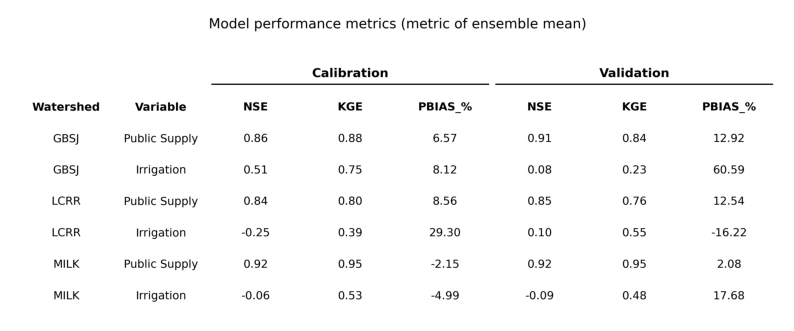

In [38]:
##### ---------- RENDER AS PNG (side-by-side calibration / validation) ----------

def render_table_image_grouped(table_df, out_path, title=None):
    # table_df has MultiIndex columns: (Period, Metric) for metric cols,
    # and flat ("Watershed", ""), ("Variable", "") for label cols
    label_cols = [("Watershed", ""), ("Variable", "")]
    metric_col_pairs = [c for c in table_df.columns if c not in label_cols]

    periods = list(dict.fromkeys([c[0] for c in metric_col_pairs]))  # ["Calibration", "Validation"]
    metrics_per_period = [c[1] for c in metric_col_pairs if c[0] == periods[0]]

    n_rows = len(table_df)
    n_label_cols = len(label_cols)
    n_metric_cols = len(metric_col_pairs)
    n_cols = n_label_cols + n_metric_cols

    fig_width = 1.1 * n_cols
    fig_height = 0.4 * (n_rows + 3)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    # build header rows: row 0 = period group labels, row 1 = metric labels
    group_header = []
    metric_header = []
    for col in label_cols:
        group_header.append("")
        metric_header.append(col[0])
    for col in metric_col_pairs:
        group_header.append(col[0])
        metric_header.append(col[1])

    cell_text = table_df.values.tolist()

    tbl = ax.table(
        cellText=cell_text,
        colLabels=metric_header,
        loc="center",
        cellLoc="center",
        bbox=[0, 0, 1, 0.85],  # leave room above for group header row
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)

    # style: no vertical gridlines, horizontal rules only, sans-serif font
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("none")
        cell.set_text_props(fontfamily="sans-serif")
        if row == 0:
            cell.set_text_props(weight="bold", fontfamily="sans-serif")
            cell.visible_edges = "B"
            cell.set_linewidth(1.0)
        elif row == n_rows:
            cell.visible_edges = "B"
            cell.set_linewidth(1.2)

    # add group header row (Calibration | Validation) manually above the table
    start = n_label_cols
    for period in periods:
        span = len(metrics_per_period)
        col_idx = start
        ax.text(
            (col_idx + span / 2) / n_cols,
            0.92,
            period,
            ha="center", va="center",
            fontsize=10, fontweight="bold", fontfamily="sans-serif",
            transform=ax.transAxes,
        )
        # underline the group
        ax.plot(
            [col_idx / n_cols + 0.005, (col_idx + span) / n_cols - 0.005],
            [0.88, 0.88],
            color="black", linewidth=1.0,
            transform=ax.transAxes,
        )
        start += span

    if title:
        ax.set_title(title, fontsize=11, fontfamily="sans-serif", pad=20)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

render_table_image_grouped(
    table_df,
    out_path=f"{out_dir}/model_performance_table.png",
    title="Model performance metrics (metric of ensemble mean)"
)

img = mpimg.imread(f"{out_dir}/model_performance_table.png")
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img)
ax.axis("off")
plt.show()

Period Watershed       Variable Calibration                          Validation                         
                                        KGE KGE_r KGE_alpha KGE_beta        KGE KGE_r KGE_alpha KGE_beta
0           GBSJ  Public Supply        0.88  0.94      1.07     1.07       0.84  0.96      1.09     1.13
1           GBSJ     Irrigation        0.75  0.76      1.01     1.08       0.23  0.73      1.39     1.61
2           LCRR  Public Supply        0.80  0.95      1.17     1.09       0.76  0.95      1.20     1.12
3           LCRR     Irrigation        0.39  0.56      1.31     1.29       0.55  0.58      1.06     0.84
4           MILK  Public Supply        0.95  0.96      0.98     0.98       0.95  0.96      1.02     1.02
5           MILK     Irrigation        0.53  0.60      1.25     0.95       0.48  0.62      1.31     1.18


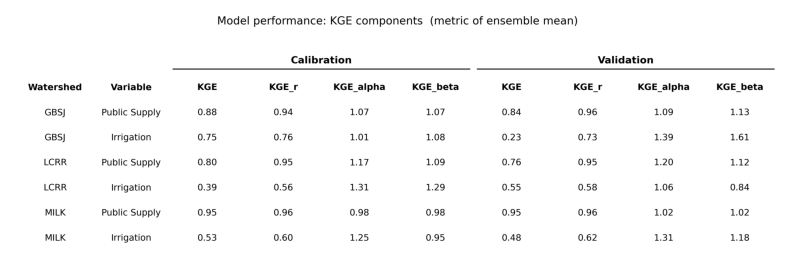

In [39]:
##### ---------- BUILD TABLE WITH KGE COMPONENTS ----------


metric_cols_kge = ["KGE", "KGE_r", "KGE_alpha", "KGE_beta"]
table_df_kge = format_summary_table_wide(summary_df_all, metric_cols_kge)

print(table_df_kge)

render_table_image_grouped(
    table_df_kge,
    out_path=f"{out_dir}/model_performance_table_kge.png",
    title="Model performance: KGE components  (metric of ensemble mean)"
)

img_kge = mpimg.imread(f"{out_dir}/model_performance_table_kge.png")
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img_kge)
ax.axis("off")
plt.show()

Period Watershed       Variable Calibration                          Validation                         
                                        NSE NSE_r NSE_alpha NSE_beta        NSE NSE_r NSE_alpha NSE_beta
0           GBSJ  Public Supply        0.86  0.94      1.07     0.03       0.91  0.96      1.09     0.06
1           GBSJ     Irrigation        0.51  0.76      1.01     0.02       0.08  0.73      1.39     0.15
2           LCRR  Public Supply        0.84  0.95      1.17     0.04       0.85  0.95      1.20     0.05
3           LCRR     Irrigation       -0.25  0.56      1.31     0.04       0.10  0.58      1.06    -0.01
4           MILK  Public Supply        0.92  0.96      0.98    -0.00       0.92  0.96      1.02     0.00
5           MILK     Irrigation       -0.06  0.60      1.25    -0.02      -0.09  0.62      1.31     0.06


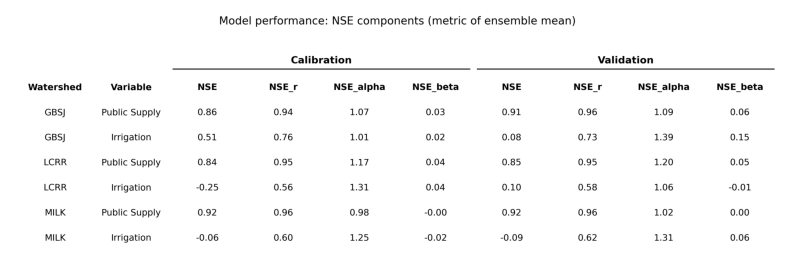

In [40]:
##### ---------- BUILD TABLE WITH NSE COMPONENTS ----------

metric_cols_nse = ["NSE", "NSE_r", "NSE_alpha", "NSE_beta"]
table_df_nse = format_summary_table_wide(summary_df_all, metric_cols_nse)

print(table_df_nse)

render_table_image_grouped(
    table_df_nse,
    out_path=f"{out_dir}/model_performance_table_nse.png",
    title="Model performance: NSE components (metric of ensemble mean)"
)

img_nse = mpimg.imread(f"{out_dir}/model_performance_table_nse.png")
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img_nse)
ax.axis("off")
plt.show()